In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from category_encoders import TargetEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.2f}'.format

In [39]:
df_original = pd.read_csv('train.csv')

In [40]:
colunas_ordinais = ['ExterQual', 'KitchenQual', 'BsmtQual']
mapeamento = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1}

df_original[colunas_ordinais] = df_original[colunas_ordinais].replace(mapeamento)

C:\Users\Felipe\AppData\Local\Temp\ipykernel_13616\2831990442.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_original[colunas_ordinais] = df_original[colunas_ordinais].replace(mapeamento)


In [41]:
df_original['BsmtQual'] = df_original['BsmtQual'].fillna('Po') 

mapeamento_completo = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}

df_original[colunas_ordinais] = df_original[colunas_ordinais].replace(mapeamento_completo)

C:\Users\Felipe\AppData\Local\Temp\ipykernel_13616\199277964.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_original[colunas_ordinais] = df_original[colunas_ordinais].replace(mapeamento_completo)


In [42]:
encoder = TargetEncoder(cols=['Neighborhood'])
df_original['Neighborhood_encoded'] = encoder.fit_transform(df_original['Neighborhood'], df_original['SalePrice'])

In [43]:
df_original['HouseAge'] = df_original['YrSold'] - df_original['YearBuilt']

In [44]:
df_original['YearsSinceRemodel'] = (
    df_original['YrSold'] - df_original['YearRemodAdd']
)

In [45]:
df_original['TotalArea'] = (
    df_original['GrLivArea']
    + df_original['TotalBsmtSF']
)

In [46]:
df_original['TotalBath'] = (
    df_original['FullBath']
    + 0.5*df_original['HalfBath']
    + df_original['BsmtFullBath']
    + 0.5*df_original['BsmtHalfBath']
)

In [52]:
num_cols = df_original.select_dtypes(include=['int64','float64'])

In [53]:
corr = num_cols.corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(10))

SalePrice              1.00
OverallQual            0.79
TotalArea              0.78
Neighborhood_encoded   0.73
GrLivArea              0.71
ExterQual              0.68
KitchenQual            0.66
GarageCars             0.64
TotalBath              0.63
GarageArea             0.62
Name: SalePrice, dtype: float64


<Axes: >

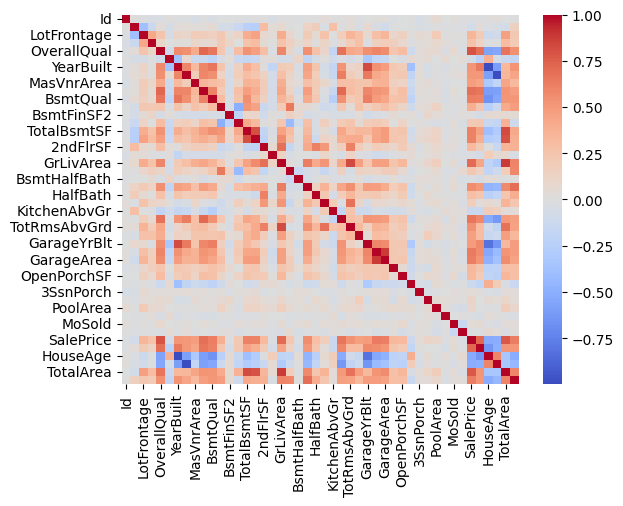

In [56]:
import seaborn as sns

sns.heatmap(
    num_cols.corr(),
    cmap='coolwarm',
    center=0
)